In [19]:
from __future__ import annotations
import pandas as pd
import numpy as np
import scanpy as sc
import scanpy.external as sce
import anndata as ad
import warnings
warnings.filterwarnings("ignore")
import hdf5plugin #in case needed for h5ad reading (if previously saved with compression)
import sys
import os

# input_path1 = str(sys.argv[1])
# input_path2 = str(sys.argv[2])

input_path1 = "/home/sofia/Projects/etmr/defaria/snRNA/data/processed/snrna_data_filt.h5ad"



print("Reading " + input_path1 + "...")
etmr1 = ad.io.read_h5ad(input_path1)
print(etmr1)




Reading /home/sofia/Projects/etmr/defaria/snRNA/data/processed/snrna_data_filt.h5ad...
AnnData object with n_obs × n_vars = 49124 × 18082
    obs: 'orig.ident', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p'
    layers: 'counts', 'scale.data'


In [20]:
etmr1.obs

,orig.ident,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt
AAACAAGCATTCGGTTACTACTCA-1-GSM8058157_KK22-H-225,GSM8058157_KK22-H-225,1395,1721.0,15.0,0.871586
AAACCAGGTTGCATCGACTACTCA-1-GSM8058157_KK22-H-225,GSM8058157_KK22-H-225,1646,2185.0,11.0,0.503432
AAACGGGCAATAACCGACTACTCA-1-GSM8058157_KK22-H-225,GSM8058157_KK22-H-225,924,1090.0,0.0,0.000000
AAACTGGGTGCACAAAACTACTCA-1-GSM8058157_KK22-H-225,GSM8058157_KK22-H-225,2196,3515.0,1.0,0.028450
AAAGATGCAATCGTGAACTACTCA-1-GSM8058157_KK22-H-225,GSM8058157_KK22-H-225,746,835.0,0.0,0.000000
...,...,...,...,...,...
TTTGGACGTGGGTGTGAGTAGGCT-1-GSM8058164_KK23-H-511,GSM8058164_KK23-H-511,1815,2322.0,30.0,1.291990
TTTGGCGGTAAGGCCGAGTAGGCT-1-GSM8058164_KK23-H-511,GSM8058164_KK23-H-511,1792,2333.0,17.0,0.728676
TTTGGCGGTATAGCGAAGTAGGCT-1-GSM8058164_KK23-H-511,GSM8058164_KK23-H-511,1705,2145.0,31.0,1.445221
TTTGGCGGTCAGGATAAGTAGGCT-1-GSM8058164_KK23-H-511,GSM8058164_KK23-H-511,705,787.0,11.0,1.397713


In [21]:
pat_info = pd.DataFrame({
    "orig.ident": [
        "GSM8058157_KK22-H-225", "GSM8058158_KK22-H-226", "GSM8058159_KK22-H-227",
        "GSM8058160_KK23-H-507", "GSM8058161_KK23-H-508", "GSM8058162_KK23-H-509",
        "GSM8058163_KK23-H-510", "GSM8058164_KK23-H-511", "GSM8058165_KK23-H-512"
    ],
    "Sample_ID": [
        "KK22-H-225", "KK22-H-226", "KK22-H-227",
        "KK23-H-507", "KK23-H-508", "KK23-H-509",
        "KK23-H-510", "KK23-H-511", "KK23-H-512"
    ],
    "Tumor_Type": [
        "C19MC", "C19MC", "Dicer",
        "C19MC", "C19MC", "C19MC",
        "C19MC", "C19MC", "C19MC"
    ]
})


pat_info



,orig.ident,Sample_ID,Tumor_Type
0,GSM8058157_KK22-H-225,KK22-H-225,C19MC
1,GSM8058158_KK22-H-226,KK22-H-226,C19MC
2,GSM8058159_KK22-H-227,KK22-H-227,Dicer
3,GSM8058160_KK23-H-507,KK23-H-507,C19MC
4,GSM8058161_KK23-H-508,KK23-H-508,C19MC
5,GSM8058162_KK23-H-509,KK23-H-509,C19MC
6,GSM8058163_KK23-H-510,KK23-H-510,C19MC
7,GSM8058164_KK23-H-511,KK23-H-511,C19MC
8,GSM8058165_KK23-H-512,KK23-H-512,C19MC


In [22]:

pat_info_indexed = pat_info.set_index("orig.ident")
etmr1.obs = etmr1.obs.join(pat_info_indexed, on="orig.ident", how="left")



This is the snRNA-seq data of 9 patient tumors. The goal is to make a separate analisis from the ones I have where I integrated the data with the reference using scanpy ingest(). I'll run some clusterization only on the tumor samples and see if I need to do some integration like cca or something else to see how the DICER tumor behaves in comparison with the C19MC tumors. DICER is very interesting because the mutant mice in the lab have a DICER mutation. 

In [23]:
etmr1.obs

,orig.ident,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,Sample_ID,Tumor_Type
AAACAAGCATTCGGTTACTACTCA-1-GSM8058157_KK22-H-225,GSM8058157_KK22-H-225,1395,1721.0,15.0,0.871586,KK22-H-225,C19MC
AAACCAGGTTGCATCGACTACTCA-1-GSM8058157_KK22-H-225,GSM8058157_KK22-H-225,1646,2185.0,11.0,0.503432,KK22-H-225,C19MC
AAACGGGCAATAACCGACTACTCA-1-GSM8058157_KK22-H-225,GSM8058157_KK22-H-225,924,1090.0,0.0,0.000000,KK22-H-225,C19MC
AAACTGGGTGCACAAAACTACTCA-1-GSM8058157_KK22-H-225,GSM8058157_KK22-H-225,2196,3515.0,1.0,0.028450,KK22-H-225,C19MC
AAAGATGCAATCGTGAACTACTCA-1-GSM8058157_KK22-H-225,GSM8058157_KK22-H-225,746,835.0,0.0,0.000000,KK22-H-225,C19MC
...,...,...,...,...,...,...,...
TTTGGACGTGGGTGTGAGTAGGCT-1-GSM8058164_KK23-H-511,GSM8058164_KK23-H-511,1815,2322.0,30.0,1.291990,KK23-H-511,C19MC
TTTGGCGGTAAGGCCGAGTAGGCT-1-GSM8058164_KK23-H-511,GSM8058164_KK23-H-511,1792,2333.0,17.0,0.728676,KK23-H-511,C19MC
TTTGGCGGTATAGCGAAGTAGGCT-1-GSM8058164_KK23-H-511,GSM8058164_KK23-H-511,1705,2145.0,31.0,1.445221,KK23-H-511,C19MC
TTTGGCGGTCAGGATAAGTAGGCT-1-GSM8058164_KK23-H-511,GSM8058164_KK23-H-511,705,787.0,11.0,1.397713,KK23-H-511,C19MC


Computing /home/sofia/Projects/etmr/defaria/snRNA/data/processed/snrna_data_filt.h5ad PCA...


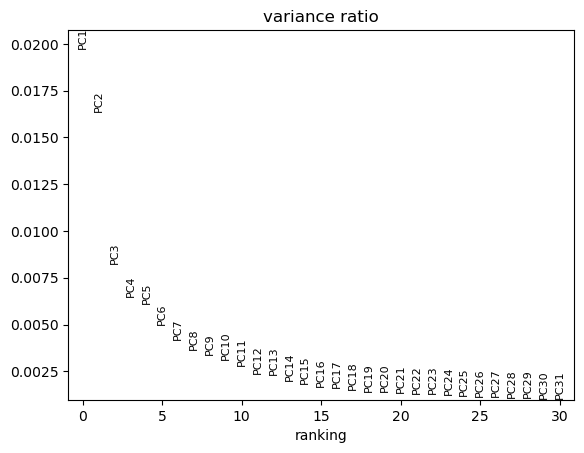

In [24]:
print("Computing " + input_path1 + " PCA...")
sc.pp.pca(etmr1, use_highly_variable=True, layer="scale.data")
sc.pl.pca_variance_ratio(etmr1)

In [25]:
print("Computing" + input_path1 + " neighbors and UMAP...")
sc.pp.neighbors(etmr1, n_neighbors=11, n_pcs=20)
sc.tl.umap(etmr1)
print("Computing" + input_path1 + " Leiden clustering...")
sc.tl.leiden(etmr1, resolution=0.5)

Computing/home/sofia/Projects/etmr/defaria/snRNA/data/processed/snrna_data_filt.h5ad neighbors and UMAP...
Computing/home/sofia/Projects/etmr/defaria/snRNA/data/processed/snrna_data_filt.h5ad Leiden clustering...


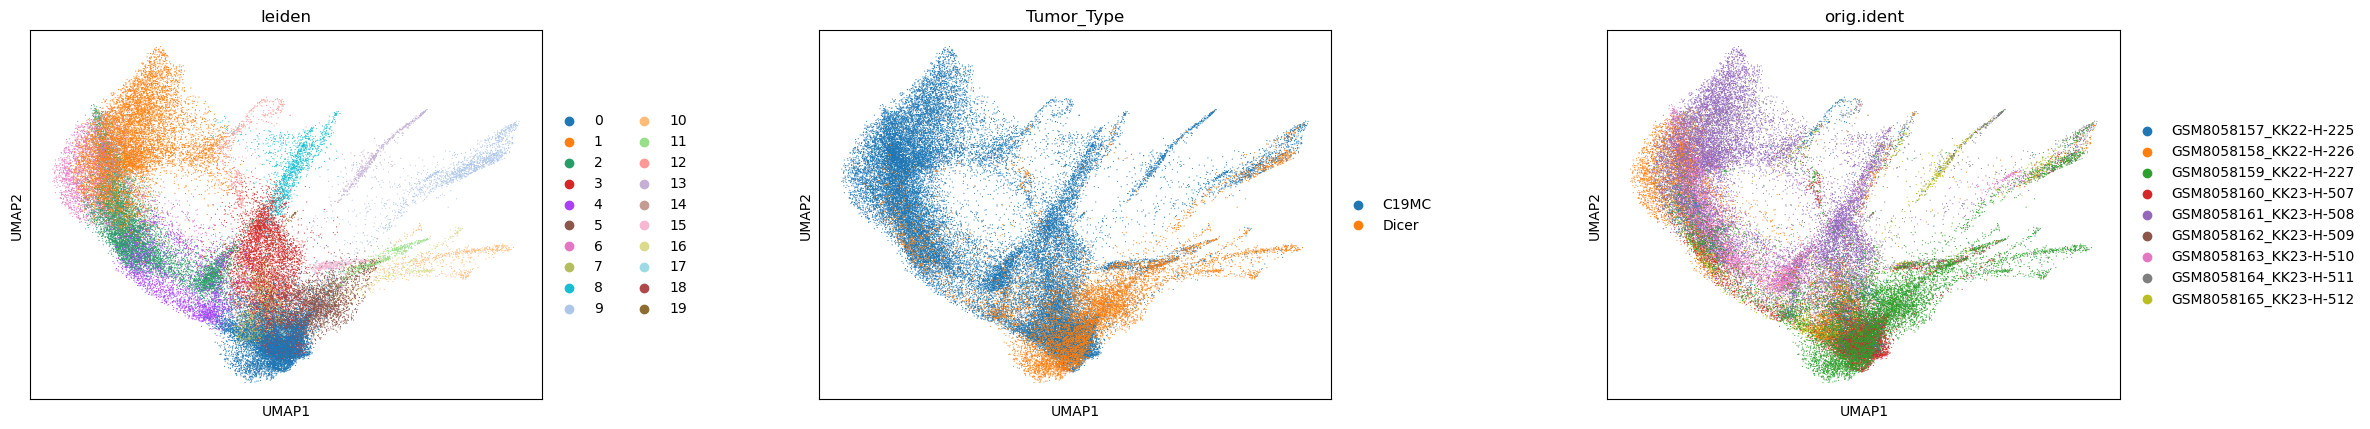

In [33]:
sc.pl.umap(etmr1, color=["leiden", "Tumor_Type", "orig.ident"], wspace=0.4)

In [27]:

sce.pp.harmony_integrate(etmr1, "Tumor_Type")

2025-12-02 14:50:42,416 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-12-02 14:51:11,230 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-12-02 14:51:11,776 - harmonypy - INFO - Iteration 1 of 10
2025-12-02 14:51:49,530 - harmonypy - INFO - Iteration 2 of 10
2025-12-02 14:52:27,110 - harmonypy - INFO - Converged after 2 iterations


In [28]:
etmr1.obsm['X_umap_unintegrated'] = etmr1.obsm['X_umap'].copy()
etmr1.obs['leiden_unintegrated'] = etmr1.obs['leiden'].copy()
sc.pp.neighbors(etmr1, use_rep='X_pca_harmony')
sc.tl.umap(etmr1, init_pos='X_pca_harmony')
sc.tl.leiden(etmr1, resolution=0.5)

In [34]:
print(etmr1)

AnnData object with n_obs × n_vars = 49124 × 18082
    obs: 'orig.ident', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'Sample_ID', 'Tumor_Type', 'leiden', 'leiden_unintegrated', 'leiden_harmony'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca', 'neighbors', 'umap', 'leiden', 'Tumor_Type_colors', 'orig.ident_colors', 'leiden_colors'
    obsm: 'X_pca', 'X_umap', 'X_pca_harmony', 'X_umap_unintegrated', 'X_umap_harmony'
    varm: 'PCs'
    layers: 'counts', 'scale.data'
    obsp: 'distances', 'connectivities'


In [36]:
idx = etmr1.obs.sort_values("Tumor_Type").index
etmr1 = etmr1[idx,]


In [37]:
etmr1.obsm['X_umap_harmony'] = etmr1.obsm['X_umap'].copy()
etmr1.obs['leiden_harmony'] = etmr1.obs['leiden'].copy()


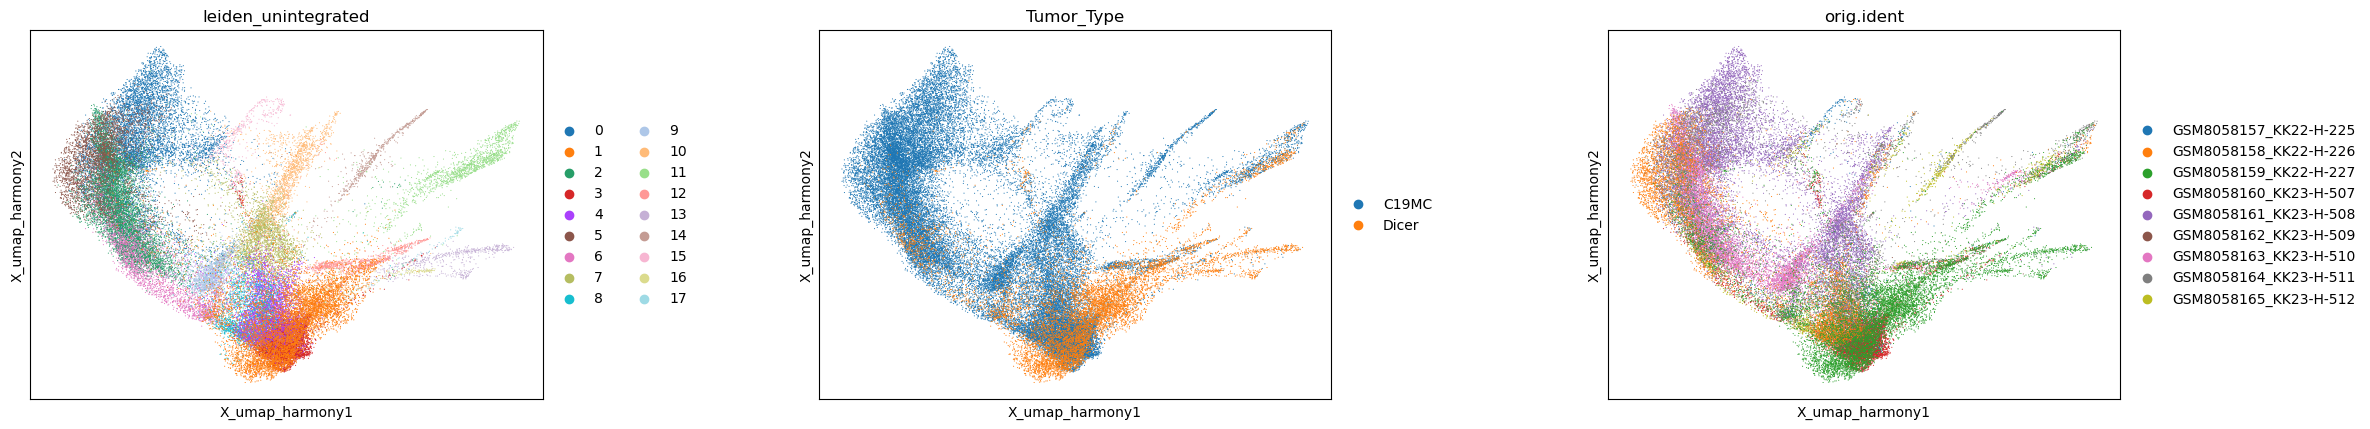

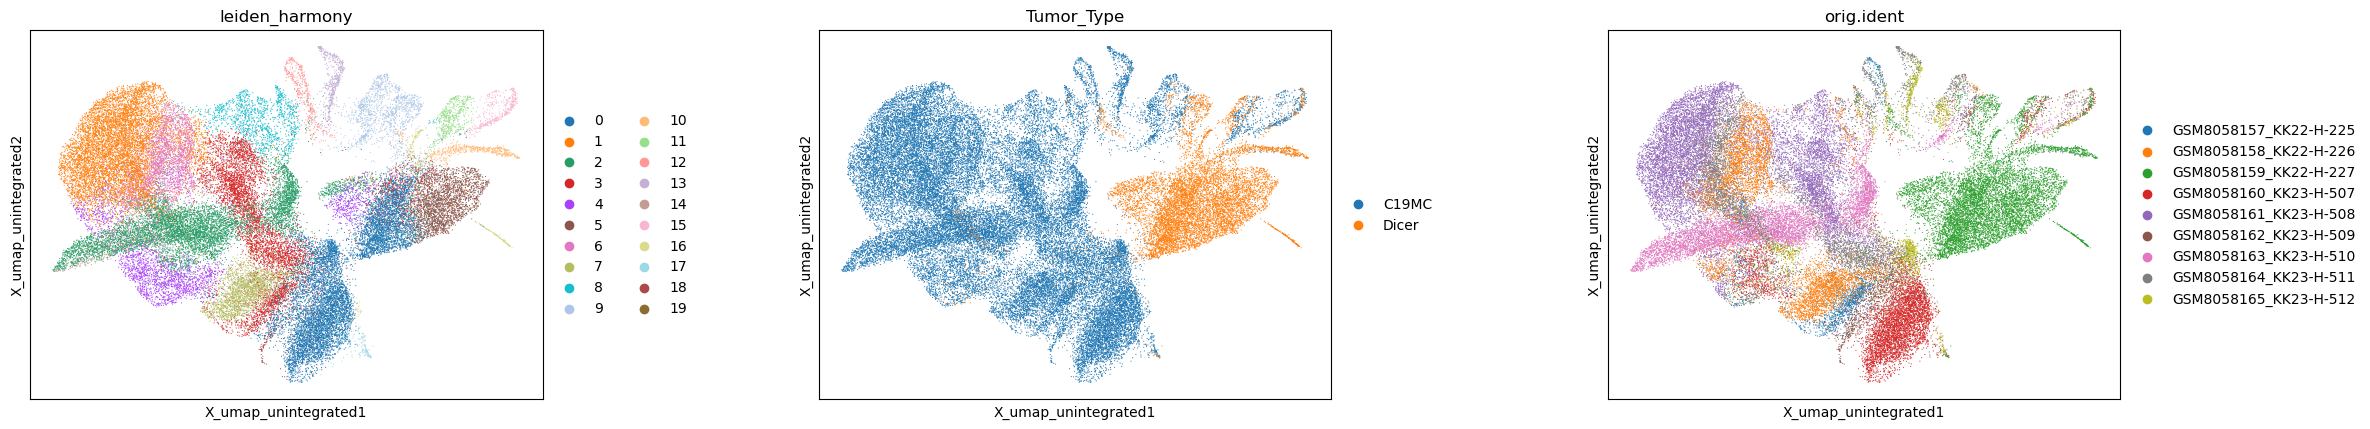

In [ ]:
sc.pl.embedding(etmr1, basis="X_umap_harmony", color=["leiden_unintegrated", "Tumor_Type", "orig.ident"], wspace=0.4)
sc.pl.embedding(etmr1, basis="X_umap_unintegrated", color=["leiden_harmony","Tumor_Type", "orig.ident"], wspace=0.4)

In [42]:
etmr1.write_h5ad("/home/sofia/Projects/etmr/defaria/snRNA/data/processed/snrna_data_umap.h5ad")
